After the review of the data set and the email of sarah i noticed that the datast its very large which detecting the 2% of 284808 which is 5678 fraud transaction that its a 2,278,464 $ loss for the company and as they detect manually the fraud transactions and they could miss detecting fraud values which  will shutdown the team effort because it will be a waste of time and it will potentialy miss the actual fraud value and cost them losing money so the recall metric will help a lot to detect out of all the actual fraud trasactions how many the mode detected and adding a F1-score metric will make a balance between the precison and recall , also there is a potential problem of inconsistent datatype which the data was typed with different teams which could lead to the model considering each diffrent name format as diffrent variable or maybe the model could crash or not telling us there is a problem and it will impact the acuracy of the model and also exporting and merging 24months dataset will lead to considering some headers as rows coliumns as rows etc ..., and alson the numeric values could have a " symbol  which python will consider it as a string datatype and will crash or considered as NaN value and it will make our model bad 




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/creditcard.csv')

print(df.shape)
print(df.dtypes)
print(df.head())

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1

In [3]:
# Check 1: missing values
print("Missing values:")
print(df.isnull().sum())

# Check 2: class distribution
print("\nClass distribution:")
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True).round(4))

# Check 3: duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Check 4: basic stats on Amount and Time
print("\nAmount stats:")
print(df['Amount'].describe())

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64

Duplicate rows: 1081

Amount stats:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [4]:
pd.set_option('display.max_rows', 100)

print("Missing values:\n", df.isnull().sum())
print("\nClass distribution (counts):\n", df['Class'].value_counts())
print("\nClass distribution (%):\n", df['Class'].value_counts(normalize=True).round(4))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nAmount stats:\n", df['Amount'].describe())

Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class distribution (counts):
 Class
0    284315
1       492
Name: count, dtype: int64

Class distribution (%):
 Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64

Duplicate rows: 1081

Amount stats:
 count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [5]:
# Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

Shape after removing duplicates: (283726, 31)
Duplicates remaining: 0


In [6]:
zero_amount = df[df['Amount'] == 0]
print("Zero amount transactions:", len(zero_amount))
print("Zero amount fraud vs legitimate:")
print(zero_amount['Class'].value_counts())

Zero amount transactions: 1808
Zero amount fraud vs legitimate:
Class
0    1783
1      25
Name: count, dtype: int64


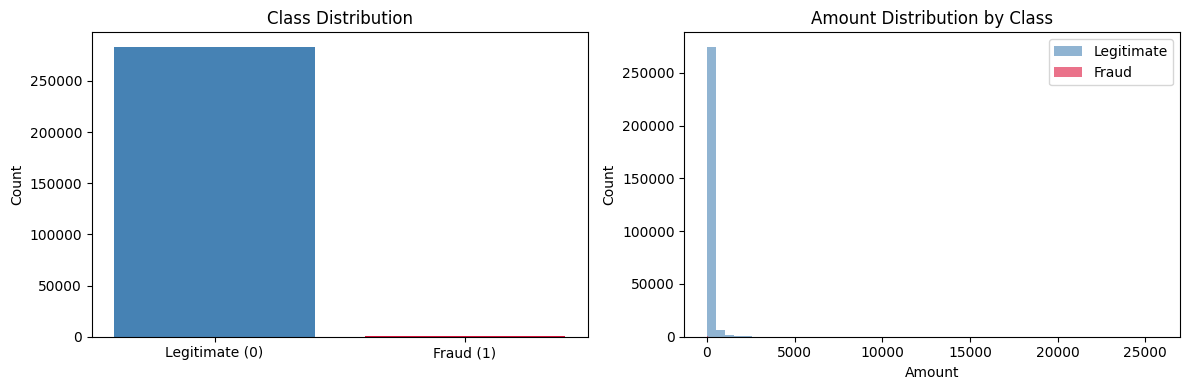

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], 
            df['Class'].value_counts().values,
            color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Amount distribution (log scale to handle skew)
axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, 
             label='Legitimate', color='steelblue')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6, 
             label='Fraud', color='crimson')
axes[1].set_title('Amount Distribution by Class')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/eda_class_and_amount.png')
plt.show()

## EDA Findings

1. The legitimate count is heavily bigger than fraud. The extreme class imbalance means accuracy is a misleading metric — we prioritize **Recall** and **F1-score**.

2. The Amount distribution has a mean of 88 with extreme values reaching 25,691 (std=250). This skew will be favoured by the model if Amount is not scaled.

3. Removing 1,081 duplicate rows before splitting avoids the risk of the model training on the same transaction twice, which would cause overfitting.